# Design 4: baseline study with Algorithm A3

From `literature-notes/main-project-idea.txt`: "a baseline study that uses the same design of Design 1, but using Algorithm A3; also, each chunk will have two slots with the name or identifier of the song and the evaluation of the song (as in Design 3)." Goals: (1) how does `evaluation` vary over time, (2) how does Algorithm A3's own running `time_averaged_aesthetic_basis` vary over time.

Same random, ergodic environment as Design 1 (uniform i.i.d. song draws) -- not Design 2/3's cyclic von Mises one. `run_design4()` runs Algorithm A3 each repeat exposure; `evaluate_a3()` learns its own `{song_id, evaluation}` chunk internally as a final step, so the run loop does NOT separately call `learn_evaluation()` afterward (unlike Design 3's Algorithm A2 loop) -- only a song's first exposure gets an explicit bootstrap placeholder chunk.

Like Design 3, chunk count grows with trial count (every distinct evaluation value is its own chunk), so retrieval scales roughly quadratically -- confirmed empirically: 500 exposures->0.5s, 1000->1.8s, 2000->7.5s, 4000->31s. NUM_EXPOSURES defaults to 2000 here for fast iteration, matching Design 3's precedent.

Change parameters below and re-run to explore. Note: set NOISE=0 for a deterministic run (per Mark's note under Design 3, likely applicable here too).

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_design4

NUM_SONGS = 100
NUM_EXPOSURES = 2000
WINDOW = 20                       # post-hoc rolling-mean window, for plotting evaluation
SEED = 42
NOISE = 0.25                      # set to 0 for a deterministic run
DECAY = 0.5

TIME_AVERAGE_MODE = "cumulative"  # Algorithm A3's own running-average mode: "cumulative" or "window"
TIME_AVERAGE_WINDOW = 20          # only used when TIME_AVERAGE_MODE == "window"

ANNOTATE_SONGS = False
ANNOTATE_MAX_LABELS = 15

## Run

In [2]:
df = run_design4(num_songs=NUM_SONGS, num_exposures=NUM_EXPOSURES, window=WINDOW,
                  seed=SEED, noise=NOISE, decay=DECAY,
                  time_average_mode=TIME_AVERAGE_MODE, time_average_window=TIME_AVERAGE_WINDOW,
                  config_path="../config.yaml",
                  output_path="../results/data/design4_baseline_a3_timeseries.csv")
df.describe()

,predicted_activation,actual_activation,aesthetic_basis,time_averaged_aesthetic_basis,evaluation,trial,complexity,evaluation_rolling_mean
count,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1881.000000
mean,0.242275,-1.822384,2.067766,2.013729,-0.628896,1046.940526,5.006842,-0.622884
std,0.360911,0.634197,0.719605,0.123328,1.624632,552.844140,2.730757,0.401566
min,-0.609530,-4.068296,0.013368,0.502192,-17.025100,8.000000,1.000000,-2.355426
25%,-0.003949,-2.275970,1.628782,2.001318,-1.264190,574.750000,3.000000,-0.859728
50%,0.200114,-1.913718,2.119740,2.065205,-0.194081,1049.500000,5.000000,-0.579149
75%,0.447144,-1.445915,2.545251,2.073091,0.557998,1524.250000,7.000000,-0.333093
max,3.326684,0.636426,5.447429,2.081983,0.999999,1999.000000,10.000000,0.330936


## Goal 1: evaluation over time

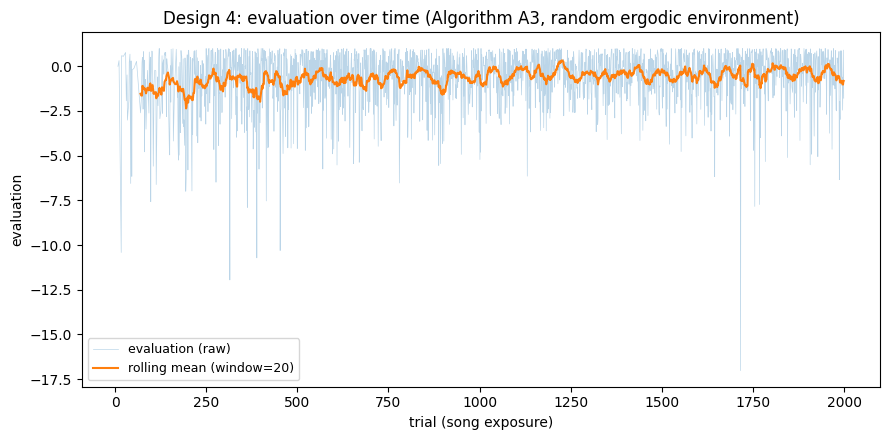

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["trial"], df["evaluation"], alpha=0.3, linewidth=0.5,
        color="tab:blue", label="evaluation (raw)")
ax.plot(df["trial"], df["evaluation_rolling_mean"], linewidth=1.5,
        color="tab:orange", label=f"rolling mean (window={WINDOW})")

if ANNOTATE_SONGS:
    step = max(1, len(df) // ANNOTATE_MAX_LABELS)
    for _, row in df.iloc[::step].iterrows():
        ax.annotate(row["actual_song_id"], (row["trial"], row["evaluation"]),
                    fontsize=7, rotation=90, textcoords="offset points", xytext=(0, 5))

ax.set_xlabel("trial (song exposure)")
ax.set_ylabel("evaluation")
ax.set_title("Design 4: evaluation over time (Algorithm A3, random ergodic environment)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("../results/figures/design4_evaluation_timeseries.png", dpi=150)

## Goal 2: time_averaged_aesthetic_basis over time

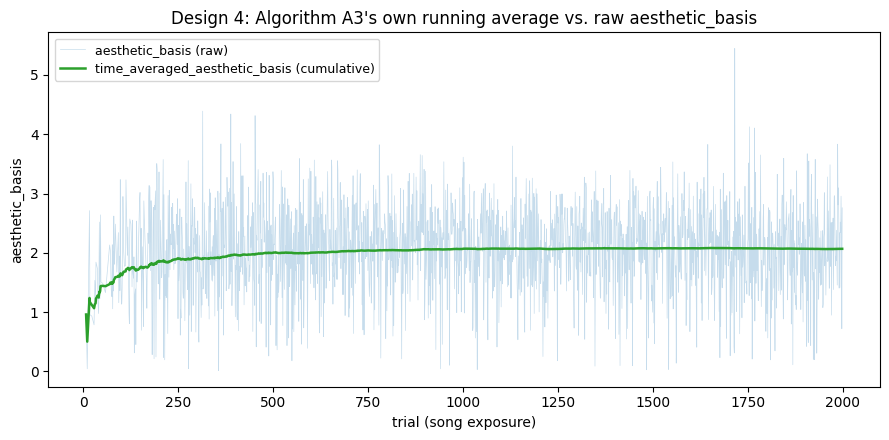

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["trial"], df["aesthetic_basis"], alpha=0.25, linewidth=0.5,
        color="tab:blue", label="aesthetic_basis (raw)")
ax.plot(df["trial"], df["time_averaged_aesthetic_basis"], linewidth=1.8,
        color="tab:green", label=f"time_averaged_aesthetic_basis ({TIME_AVERAGE_MODE})")
ax.set_xlabel("trial (song exposure)")
ax.set_ylabel("aesthetic_basis")
ax.set_title("Design 4: Algorithm A3's own running average vs. raw aesthetic_basis")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("../results/figures/design4_time_averaged_basis.png", dpi=150)

`time_averaged_aesthetic_basis` is computed live, inside the algorithm itself, trial by trial -- not a post-hoc pandas rolling mean like the orange line in the first plot. Compare its steady-state level here to Design 1's aesthetic_basis rolling mean (~1.3-1.4): since Design 4 uses the same environment and Algorithm A as its foundation, they should converge to a similar range.